In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import matplotlib.pyplot as plt
import numpy as np
import torch


(150,)


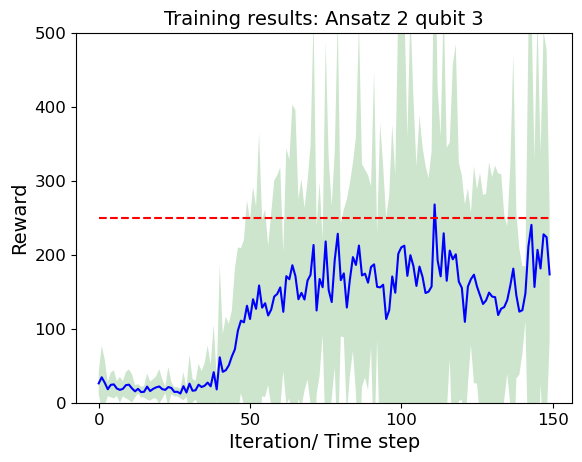

In [ ]:
base_path = os.getcwd()

complete_data = []
for i in range(5):
    remaining_path = f"/results/ansatz 1 qubit 2/"
    filename = f"seed {i+1}/rewards_per_episode_seed_{i}.npy"
    complete_data.append(np.load(base_path+remaining_path+filename))

complete_data = np.array(complete_data)
mean_data = np.mean(complete_data , axis = 0)
print(mean_data.shape)
var_data = np.var(complete_data,axis =0)
error = np.sqrt(var_data)

# plt.errorbar()
fig,ax = plt.subplots()
ax.plot(np.arange(len(mean_data)),mean_data,color = "blue")
ax.plot(np.arange(len(mean_data)),np.zeros(len(mean_data))+250,color="red",linestyle='--')
# ax.fill_between(np.arange(len(mean_data)), mean_data+2*error, mean_data-2*error, facecolor='green', interpolate=True,alpha =0.2)
ax.fill_between(np.arange(len(mean_data)), mean_data-2*error, mean_data+2*error, facecolor='green', interpolate=True,alpha =0.2)
ax.set_ylabel("Reward", fontsize=14)
ax.set_ylim([0,500])
ax.set_xlabel("Iteration/ Time step", fontsize=14)
ax.set_xticks(np.arange(0,160,50))
ax.set_title("Training results: Ansatz 2 qubit 3", fontsize=14)
ax.tick_params(labelsize=12)

plt.show()
# plt.fill_between(x, y1, y2, where=y2 <= y1, facecolor='red', interpolate=True)


(150,)


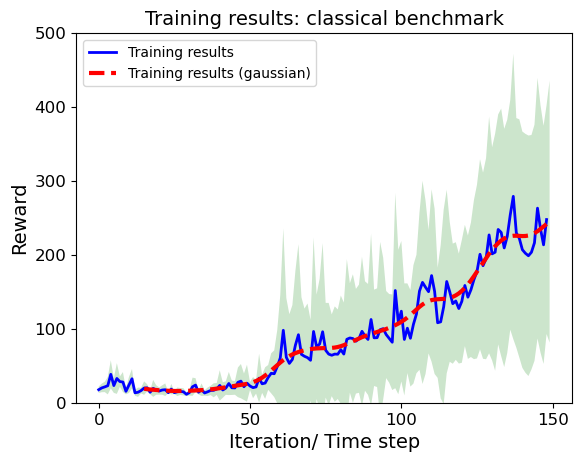

In [59]:
from matplotlib.lines import lineStyles
from scipy.ndimage import gaussian_filter1d

def plot_with_gaussian_2(time_data: np.ndarray,
                       data: np.ndarray,
                       window_size: int,
                       label: str,
                       color: str,
                       linestyle: str,
                       start: int,
                       stop: int,
                       axes,
                       plot_second_line=True,
                       sigma_factor: float = 0.3
                       ):
    sigma = window_size * sigma_factor
    data_gauss = gaussian_filter1d(data, sigma=sigma, mode='nearest')

    axes.plot(time_data[0:stop], data[0:stop],
             label=label, linestyle=linestyle, color=color,linewidth =2)
    if(plot_second_line == True):
        axes.plot(time_data[start:stop], data_gauss[start:stop],
                label=label + ' (gaussian)', linewidth=3, color='red',linestyle='dashed')
    return

base_path = os.getcwd()
ansatz_number = 2
qubit_number = 3
complete_data = []
for i in range(5):
    # remaining_path = f"/results/ansatz {ansatz_number} qubit {qubit_number}/"
    remaining_path = f"/results/classical benchmark/"
    filename = f"seed {i+1}/rewards_per_episode_seed_{i}.npy"
    complete_data.append(np.load(base_path+remaining_path+filename))

complete_data = np.array(complete_data)
mean_data = np.mean(complete_data , axis = 0)
print(mean_data.shape)
var_data = np.var(complete_data,axis =0)
error = np.sqrt(var_data)

start       = 15
stop        = -1
window_size = start

fig,ax = plt.subplots()
time_data = np.arange(len(mean_data))
plot_with_gaussian_2(time_data,
                     mean_data,
                     window_size,
                     r'Training results', 'blue', 'solid',
                     start, stop, ax)
ax.fill_between(np.arange(len(mean_data)), mean_data-error, mean_data+error, facecolor='green', interpolate=True,alpha =0.2)
ax.set_ylabel("Reward", fontsize=14)
ax.set_ylim([0,500])
ax.set_xlabel("Iteration/ Time step", fontsize=14)
ax.set_xticks(np.arange(0,160,50))
# ax.set_title(f"Training results: Ansatz {ansatz_number} qubit {qubit_number}", fontsize=14)
ax.set_title(f"Training results: classical benchmark", fontsize=14)
ax.tick_params(labelsize=12)
plt.legend()

# plt.savefig(base_path+remaining_path+f"ansatz_{ansatz_number}_qubit_{qubit_number}.png")
plt.savefig(base_path+remaining_path+f"classical_benchmark.png")
plt.show()



(150,)
(150,)


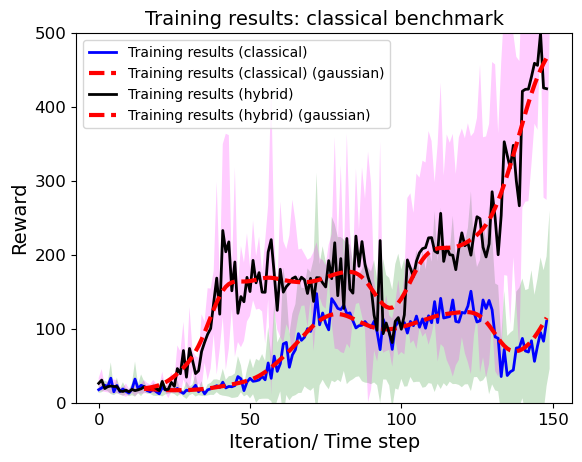

In [14]:
from matplotlib.lines import lineStyles
from scipy.ndimage import gaussian_filter1d
def plot_with_gaussian_2(time_data: np.ndarray,
                       data: np.ndarray,
                       window_size: int,
                       label: str,
                       color: str,
                       linestyle: str,
                       start: int,
                       stop: int,
                       axes,
                       plot_second_line=True,
                       sigma_factor: float = 0.3
                       ):
    sigma = window_size * sigma_factor
    data_gauss = gaussian_filter1d(data, sigma=sigma, mode='nearest')

    axes.plot(time_data[0:stop], data[0:stop],
             label=label, linestyle=linestyle, color=color,linewidth =2)
    if(plot_second_line == True):
        axes.plot(time_data[start:stop], data_gauss[start:stop],
                label=label + ' (gaussian)', linewidth=3, color='red',linestyle='dashed')
    return

base_path = os.getcwd()
ansatz_number = 2
qubit_number = 3
complete_data_classical = []
complete_data_hybrid = []
for i in range(5):
    # remaining_path = f"/results/ansatz {ansatz_number} qubit {qubit_number}/"
    remaining_path_classical = f"/results/classical benchmark_421 params/"
    remaining_path_hybrid = f"/results/ansatz {ansatz_number} qubit {qubit_number}/"
    filename = f"seed {i+1}/rewards_per_episode_seed_{i}.npy"
    complete_data_classical.append(np.load(base_path+remaining_path_classical+filename))
    complete_data_hybrid.append(np.load(base_path+remaining_path_hybrid+filename))


complete_data_classical = np.array(complete_data_classical)
mean_data_classical = np.mean(complete_data_classical , axis = 0)
print(mean_data_classical.shape)
var_data_classical = np.var(complete_data_classical,axis =0)
error_classical = np.sqrt(var_data_classical)


complete_data_hybrid = np.array(complete_data_hybrid)
mean_data_hybrid = np.mean(complete_data_hybrid , axis = 0)
print(mean_data_hybrid.shape)
var_data_hybrid = np.var(complete_data_hybrid,axis =0)
error_hybrid = np.sqrt(var_data_hybrid)

start       = 15
stop        = -1
window_size = start

fig,ax = plt.subplots()
time_data = np.arange(len(mean_data_classical))
plot_with_gaussian_2(time_data,
                     mean_data_classical,
                     window_size,
                     r'Training results (classical)', 'blue', 'solid',
                     start, stop, ax)
plot_with_gaussian_2(time_data,
                     mean_data_hybrid,
                     window_size,
                     r'Training results (hybrid)', 'black', 'solid',
                     start, stop, ax)

ax.fill_between(np.arange(len(mean_data_classical)), mean_data_classical-error_classical, mean_data_classical+error_classical, facecolor='green', interpolate=True,alpha =0.2)
ax.fill_between(np.arange(len(mean_data_hybrid)), mean_data_hybrid-error_hybrid, mean_data_hybrid+error_hybrid, facecolor='magenta', interpolate=True,alpha =0.2)
ax.set_ylabel("Reward", fontsize=14)
ax.set_ylim([0,500])
ax.set_xlabel("Iteration/ Time step", fontsize=14)
ax.set_xticks(np.arange(0,160,50))
# ax.set_title(f"Training results: Ansatz {ansatz_number} qubit {qubit_number}", fontsize=14)
ax.set_title(f"Training results: classical benchmark", fontsize=14)
ax.tick_params(labelsize=12)
plt.legend()

# plt.savefig(base_path+remaining_path+f"ansatz_{ansatz_number}_qubit_{qubit_number}.png")
plt.savefig(base_path+f"/results/"+f"classical_hybrid_compare_benchmark.png")
plt.show()

(150,)
(150,)
(150,)
(150,)
(150,)
(150,)


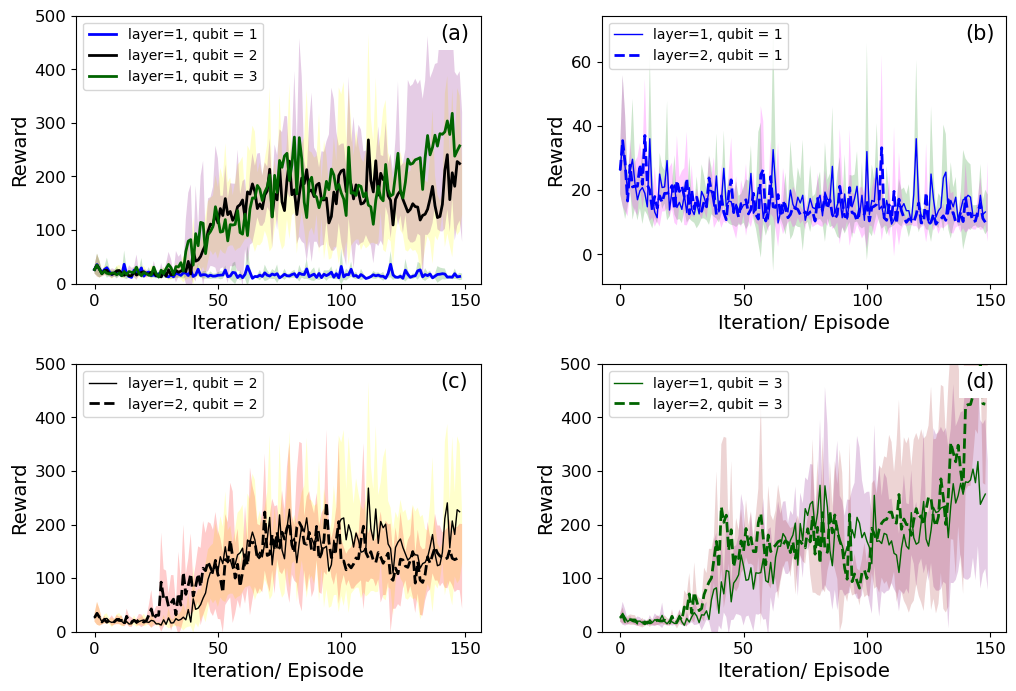

In [2]:
from matplotlib.lines import lineStyles
from scipy.ndimage import gaussian_filter1d
def plot_with_gaussian_2(time_data: np.ndarray,
                       data: np.ndarray,
                       window_size: int,
                       label: str,
                       color: str,
                       linestyle: str,
                       start: int,
                       stop: int,
                       axes,
                       linewidth=2,
                       plot_second_line=True,
                       sigma_factor: float = 0.3
                       ):
    sigma = window_size * sigma_factor
    data_gauss = gaussian_filter1d(data, sigma=sigma, mode='nearest')

    axes.plot(time_data[0:stop], data[0:stop],
             label=label, linestyle=linestyle, color=color,linewidth =linewidth)
    if(plot_second_line == True):
        axes.plot(time_data[start:stop], data_gauss[start:stop],
                label=label + ' (gaussian)', linewidth=3, color='red',linestyle='dashed')
    return


def extaction_of_averaged_data_results(file_base_path):
    complete_data = []
    for i in range(5):
        # remaining_path = f"/results/ansatz {ansatz_number} qubit {qubit_number}/"
        # # remaining_path = f"/results/classical benchmark/"
        filename = f"seed {i+1}/rewards_per_episode_seed_{i}.npy"
        complete_data.append(np.load(file_base_path+filename))

    complete_data = np.array(complete_data)
    mean_data = np.mean(complete_data , axis = 0)
    print(mean_data.shape)
    var_data = np.var(complete_data,axis =0)
    error = np.sqrt(var_data)
    return([mean_data,var_data,error])


base_path = os.getcwd()
ansatz_number = 2
qubit_number = 3
# remaining_path_hybrid = f"/results/ansatz {ansatz_number} qubit {qubit_number}/"
mean_1,var_1,error_1 = extaction_of_averaged_data_results(base_path+f"/results/ansatz {1} qubit {1}/")
mean_2,var_2,error_2 = extaction_of_averaged_data_results(base_path+f"/results/ansatz {1} qubit {2}/")
mean_3,var_3,error_3 = extaction_of_averaged_data_results(base_path+f"/results/ansatz {1} qubit {3}/")
mean_4,var_4,error_4 = extaction_of_averaged_data_results(base_path+f"/results/ansatz {2} qubit {1}/")
mean_5,var_5,error_5 = extaction_of_averaged_data_results(base_path+f"/results/ansatz {2} qubit {2}/")
mean_6,var_6,error_6 = extaction_of_averaged_data_results(base_path+f"/results/ansatz {2} qubit {3}/")


start       = 15
stop        = -1
window_size = start
hspace = 0.3
wspace = 0.3
fig, axes = plt.subplots(2, 2, figsize=(12, 8),
                         gridspec_kw={'hspace': hspace, 'wspace': wspace})
time_data = np.arange(len(mean_1))

ax1 = axes[0,0]
ax2 = axes[0,1]
ax3 = axes[1,0]
ax4 = axes[1,1]


plot_with_gaussian_2(time_data,
                     mean_1,
                     window_size,
                     r'layer=1, qubit = 1', 'blue', 'solid',
                     start, stop, ax1,plot_second_line=False)
plot_with_gaussian_2(time_data,
                     mean_2,
                     window_size,
                     r'layer=1, qubit = 2', 'black', 'solid',
                     start, stop, ax1,plot_second_line=False)
plot_with_gaussian_2(time_data,
                     mean_3,
                     window_size,
                     r'layer=1, qubit = 3', 'darkgreen', 'solid',
                     start, stop, ax1,plot_second_line=False)
ax1.fill_between(np.arange(len(mean_1)), mean_1-error_1, mean_1+error_1, facecolor='green', interpolate=True,alpha =0.2)
ax1.fill_between(np.arange(len(mean_2)), mean_2-error_2, mean_2+error_2, facecolor='yellow', interpolate=True,alpha =0.2)
ax1.fill_between(np.arange(len(mean_3)), mean_3-error_3, mean_3+error_3, facecolor='purple', interpolate=True,alpha =0.2)
ax1.set_ylabel("Reward", fontsize=14)
ax1.set_ylim([0,500])
ax1.set_xlabel("Iteration/ Episode", fontsize=14)
ax1.set_xticks(np.arange(0,160,50))
ax1.legend()

plot_with_gaussian_2(time_data,
                     mean_1,
                     window_size,
                     r'layer=1, qubit = 1', 'blue', 'solid',
                     start, stop, ax2,linewidth=1,plot_second_line=False)
plot_with_gaussian_2(time_data,
                     mean_4,
                     window_size,
                     r'layer=2, qubit = 1', 'blue', '--',
                     start, stop, ax2,linewidth=2,plot_second_line=False)
ax2.fill_between(np.arange(len(mean_1)), mean_1-error_1, mean_1+error_1, facecolor='green', interpolate=True,alpha =0.2)
ax2.fill_between(np.arange(len(mean_4)), mean_4-error_4, mean_4+error_4, facecolor='magenta', interpolate=True,alpha =0.2)
ax2.set_ylabel("Reward", fontsize=14)
# ax2.set_ylim([0,500])
ax2.set_xlabel("Iteration/ Episode", fontsize=14)
ax2.set_xticks(np.arange(0,160,50))
ax2.legend()

plot_with_gaussian_2(time_data,
                     mean_2,
                     window_size,
                     r'layer=1, qubit = 2', 'black', 'solid',
                     start, stop, ax3,linewidth=1,plot_second_line=False)

plot_with_gaussian_2(time_data,
                     mean_5,
                     window_size,
                     r'layer=2, qubit = 2', 'black', '--',
                     start, stop, ax3,linewidth=2,plot_second_line=False)
ax3.fill_between(np.arange(len(mean_2)), mean_2-error_2, mean_2+error_2, facecolor='yellow', interpolate=True,alpha =0.2)
ax3.fill_between(np.arange(len(mean_5)), mean_5-error_5, mean_5+error_5, facecolor='red', interpolate=True,alpha =0.2)
ax3.set_ylabel("Reward", fontsize=14)
ax3.set_ylim([0,500])
ax3.set_xlabel("Iteration/ Episode", fontsize=14)
ax3.set_xticks(np.arange(0,160,50))
ax3.legend()

plot_with_gaussian_2(time_data,
                     mean_3,
                     window_size,
                     r'layer=1, qubit = 3', 'darkgreen', 'solid',
                     start, stop, ax4,linewidth=1,plot_second_line=False)

plot_with_gaussian_2(time_data,
                     mean_6,
                     window_size,
                     r'layer=2, qubit = 3', 'darkgreen', '--',
                     start, stop, ax4,plot_second_line=False)
ax4.fill_between(np.arange(len(mean_3)), mean_3-error_3, mean_3+error_3, facecolor='purple', interpolate=True,alpha =0.2)
ax4.fill_between(np.arange(len(mean_6)), mean_6-error_6, mean_6+error_6, facecolor='brown', interpolate=True,alpha =0.2)
ax4.set_ylabel("Reward", fontsize=14)
ax4.set_ylim([0,500])
# ax4.set_yticks(ticks=np.arange(0,160,50))
# ax4.set_yticklabels([])
ax4.set_xlabel("Iteration/ Episode", fontsize=14)
ax4.set_xticks(np.arange(0,160,50))
ax4.legend()


# ax.set_ylabel("Reward", fontsize=14)
# ax.set_ylim([0,500])
# ax.set_xlabel("Iteration/ Time step", fontsize=14)
# ax.set_xticks(np.arange(0,160,50))
# ax.set_title(f"Training results: Ansatz {ansatz_number} qubit {qubit_number}", fontsize=14)
# plt.title(f"Training results: Quantum comparison", fontsize=14)
ax1.tick_params(labelsize=12)
ax2.tick_params(labelsize=12)
ax3.tick_params(labelsize=12)
ax4.tick_params(labelsize=12)

subplot_labels = ['(a)', '(b)','(c)','(d)']
for ax, label in zip(axes.flat, subplot_labels):
    ax.text(0.9, 0.97, label,
            transform=ax.transAxes,
            fontsize=15,
            va='top', ha='left',
            bbox=dict(boxstyle='square',
                      facecolor='white',
                      edgecolor='none',
                      linewidth=1.0,
                      alpha=1.0))

# plt.savefig(base_path+remaining_path+f"ansatz_{ansatz_number}_qubit_{qubit_number}.png")
plt.savefig(base_path+f"/results/"+f"quantum_compare.png")
plt.show()

(150,)
(150,)
(150,)
(150,)
(150,)
(150,)
(150,)
(150,)


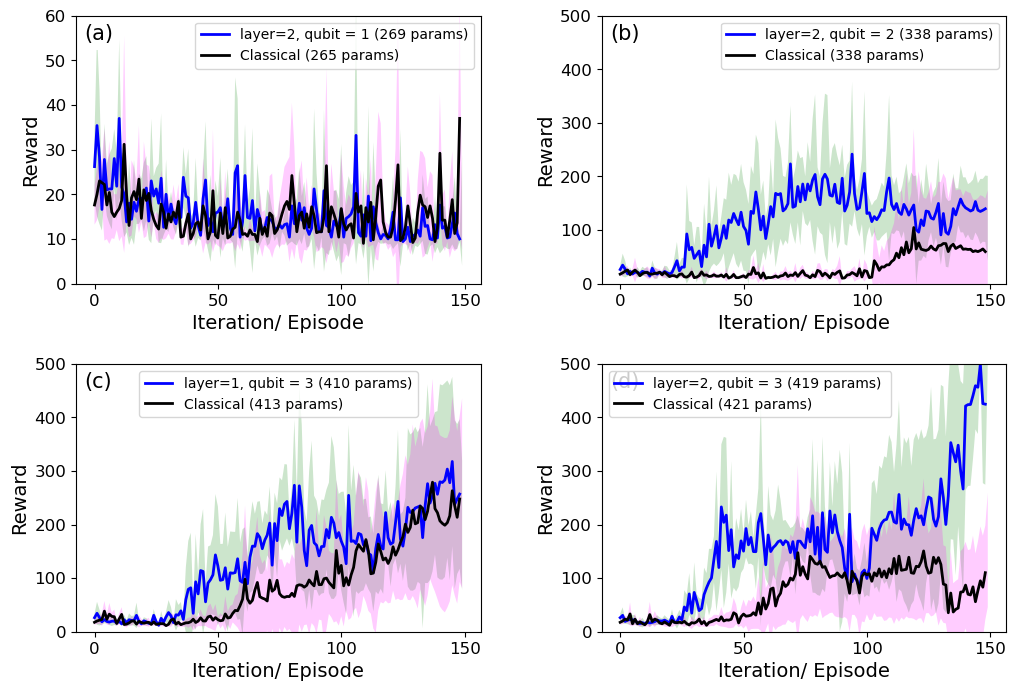

In [48]:
from matplotlib.lines import lineStyles
from scipy.ndimage import gaussian_filter1d
def plot_with_gaussian_2(time_data: np.ndarray,
                       data: np.ndarray,
                       window_size: int,
                       label: str,
                       color: str,
                       linestyle: str,
                       start: int,
                       stop: int,
                       axes,
                       linewidth=2,
                       plot_second_line=True,
                       sigma_factor: float = 0.3
                       ):
    sigma = window_size * sigma_factor
    data_gauss = gaussian_filter1d(data, sigma=sigma, mode='nearest')

    axes.plot(time_data[0:stop], data[0:stop],
             label=label, linestyle=linestyle, color=color,linewidth =linewidth)
    if(plot_second_line == True):
        axes.plot(time_data[start:stop], data_gauss[start:stop],
                label=label + ' (gaussian)', linewidth=3, color='red',linestyle='dashed')
    return


def extaction_of_averaged_data_results(file_base_path):
    complete_data = []
    for i in range(5):
        # remaining_path = f"/results/ansatz {ansatz_number} qubit {qubit_number}/"
        # # remaining_path = f"/results/classical benchmark/"
        filename = f"seed {i+1}/rewards_per_episode_seed_{i}.npy"
        complete_data.append(np.load(file_base_path+filename))

    complete_data = np.array(complete_data)
    mean_data = np.mean(complete_data , axis = 0)
    print(mean_data.shape)
    var_data = np.var(complete_data,axis =0)
    error = np.sqrt(var_data)
    return([mean_data,var_data,error])


base_path = os.getcwd()
ansatz_number = 2
qubit_number = 3
# remaining_path_hybrid = f"/results/ansatz {ansatz_number} qubit {qubit_number}/"
remaining_path_classical = f"/results/classical benchmark_421 params/"

mean_1,var_1,error_1 = extaction_of_averaged_data_results(base_path+f"/results/ansatz {2} qubit {1}/")
mean_2,var_2,error_2 = extaction_of_averaged_data_results(base_path+f"/results/classical benchmark_265 params/")
mean_3,var_3,error_3 = extaction_of_averaged_data_results(base_path+f"/results/ansatz {2} qubit {2}/")
mean_4,var_4,error_4 = extaction_of_averaged_data_results(base_path+f"/results/classical benchmark_338 params/")
mean_5,var_5,error_5 = extaction_of_averaged_data_results(base_path+f"/results/ansatz {1} qubit {3}/")
mean_6,var_6,error_6 = extaction_of_averaged_data_results(base_path+f"/results/classical benchmark/")
mean_7,var_7,error_7 = extaction_of_averaged_data_results(base_path+f"/results/ansatz {2} qubit {3}/")
mean_8,var_8,error_8 = extaction_of_averaged_data_results(base_path+f"/results/classical benchmark_421 params/")

start       = 15
stop        = -1
window_size = start
hspace = 0.3
wspace = 0.3
fig, axes = plt.subplots(2, 2, figsize=(12, 8),
                         gridspec_kw={'hspace': hspace, 'wspace': wspace})
time_data = np.arange(len(mean_1))

ax1 = axes[0,0]
ax2 = axes[0,1]
ax3 = axes[1,0]
ax4 = axes[1,1]


plot_with_gaussian_2(time_data,
                     mean_1,
                     window_size,
                     r'layer=2, qubit = 1 (269 params)', 'blue', 'solid',
                     start, stop, ax1,plot_second_line=False)
plot_with_gaussian_2(time_data,
                     mean_2,
                     window_size,
                     r'Classical (265 params)', 'black', 'solid',
                     start, stop, ax1,plot_second_line=False)

ax1.fill_between(np.arange(len(mean_1)), mean_1-error_1, mean_1+error_1, facecolor='green', interpolate=True,alpha =0.2)
ax1.fill_between(np.arange(len(mean_2)), mean_2-error_2, mean_2+error_2, facecolor='magenta', interpolate=True,alpha =0.2)
ax1.set_ylabel("Reward", fontsize=14)
ax1.set_ylim([0,60])
ax1.set_xlabel("Iteration/ Episode", fontsize=14)
ax1.set_xticks(np.arange(0,160,50))
ax1.legend()

plot_with_gaussian_2(time_data,
                     mean_3,
                     window_size,
                     r'layer=2, qubit = 2 (338 params)', 'blue', 'solid',
                     start, stop, ax2,linewidth=2,plot_second_line=False)
plot_with_gaussian_2(time_data,
                     mean_4,
                     window_size,
                     r'Classical (338 params)', 'black', 'solid',
                     start, stop, ax2,linewidth=2,plot_second_line=False)
ax2.fill_between(np.arange(len(mean_3)), mean_3-error_3, mean_3+error_3, facecolor='green', interpolate=True,alpha =0.2)
ax2.fill_between(np.arange(len(mean_4)), mean_4-error_4, mean_4+error_4, facecolor='magenta', interpolate=True,alpha =0.2)
ax2.set_ylabel("Reward", fontsize=14)
ax2.set_ylim([0,500])
ax2.set_xlabel("Iteration/ Episode", fontsize=14)
ax2.set_xticks(np.arange(0,160,50))
ax2.legend()

plot_with_gaussian_2(time_data,
                     mean_5,
                     window_size,
                     r'layer=1, qubit = 3 (410 params)', 'blue', 'solid',
                     start, stop, ax3,linewidth=2,plot_second_line=False)

plot_with_gaussian_2(time_data,
                     mean_6,
                     window_size,
                     r'Classical (413 params)', 'black', 'solid',
                     start, stop, ax3,linewidth=2,plot_second_line=False)
ax3.fill_between(np.arange(len(mean_5)), mean_5-error_5, mean_5+error_5, facecolor='green', interpolate=True,alpha =0.2)
ax3.fill_between(np.arange(len(mean_6)), mean_6-error_6, mean_6+error_6, facecolor='magenta', interpolate=True,alpha =0.2)
ax3.set_ylabel("Reward", fontsize=14)
ax3.set_ylim([0,500])
ax3.set_xlabel("Iteration/ Episode", fontsize=14)
ax3.set_xticks(np.arange(0,160,50))
ax3.legend()

plot_with_gaussian_2(time_data,
                     mean_7,
                     window_size,
                     r'layer=2, qubit = 3 (419 params) ', 'blue', 'solid',
                     start, stop, ax4,linewidth=2,plot_second_line=False)

plot_with_gaussian_2(time_data,
                     mean_8,
                     window_size,
                     r'Classical (421 params)', 'black', 'solid',
                     start, stop, ax4,plot_second_line=False)
ax4.fill_between(np.arange(len(mean_7)), mean_7-error_7, mean_7+error_7, facecolor='green', interpolate=True,alpha =0.2)
ax4.fill_between(np.arange(len(mean_8)), mean_8-error_8, mean_8+error_8, facecolor='magenta', interpolate=True,alpha =0.2)
ax4.set_ylabel("Reward", fontsize=14)
ax4.set_ylim([0,500])
# ax4.set_yticks(ticks=np.arange(0,160,50))
# ax4.set_yticklabels([])
ax4.set_xlabel("Iteration/ Episode", fontsize=14)
ax4.set_xticks(np.arange(0,160,50))
ax4.legend()


# ax.set_ylabel("Reward", fontsize=14)
# ax.set_ylim([0,500])
# ax.set_xlabel("Iteration/ Time step", fontsize=14)
# ax.set_xticks(np.arange(0,160,50))
# ax.set_title(f"Training results: Ansatz {ansatz_number} qubit {qubit_number}", fontsize=14)
ax1.tick_params(labelsize=12)
ax2.tick_params(labelsize=12)
ax3.tick_params(labelsize=12)
ax4.tick_params(labelsize=12)

subplot_labels = ['(a)', '(b)','(c)','(d)']
for ax, label in zip(axes.flat, subplot_labels):
    ax.text(0.02, 0.97, label,
            transform=ax.transAxes,
            fontsize=15,
            va='top', ha='left',
            bbox=dict(boxstyle='square',
                      facecolor='white',
                      edgecolor='none',
                      linewidth=1.0,
                      alpha=1.0))


# plt.savefig(base_path+remaining_path+f"ansatz_{ansatz_number}_qubit_{qubit_number}.png")
plt.savefig(base_path+f"/results/"+f"quantum_classical_compare.png")
plt.show()

In [8]:
import os
import torch
from class_defns.utility_functions import loading_dot_pt_files,plotting_testing_plot

ansatz_number = 1
qubit_number = 1
seed = 4
base_path = os.getcwd()
remaining_path_classical = f"/results/classical benchmark_421 params/"
remaining_path_hybrid = f"/results/ansatz {ansatz_number} qubit {qubit_number}/"

network_classical = loading_dot_pt_files(base_path+remaining_path_classical+ f"seed {seed+1}/ansatz_1_seed_{seed}.pt")
network_hybrid = loading_dot_pt_files(base_path+remaining_path_hybrid+ f"seed {seed+1}/ansatz_1_seed_{seed}.pt")

total_params_classical = sum(p.numel() for p in network_classical.parameters())
total_params_hybrid = sum(p.numel() for p in network_hybrid.parameters())

print(total_params_classical)
print(total_params_hybrid)


421
266


In [10]:
import class_defns.classical_head_classes as chc
import torch.nn as nn
layer_geometry=torch.tensor([4,2,2,64,2],dtype=torch.int)
activation_functions=nn.ModuleList([nn.ReLU(),nn.ReLU(),nn.ReLU(),nn.Identity()])

new_network = chc.neural_net(layer_geometry=layer_geometry,activation_functions=activation_functions)

print(sum(p.numel() for p in new_network.parameters()))

338
